# Enumeration

Many of mixle's discrete distributions can enumerate their support in decreasing-probability order - walk the possible values from most to least likely, exactly and lazily. That single primitive underpins a lot: exact decoding (the k most probable outputs), exact discrete computation (entropy, the mass-covering set, marginals) where you'd otherwise reach for Monte Carlo, and probability-ranked search through structured models. This notebook covers the basic surface, then the parts that make it powerful - laziness at scale, exactness versus sampling, and a budgeted seek index for supports too large to ever list.


In [1]:
import numpy as np
import time
import matplotlib.pyplot as plt
%matplotlib inline
from mixle.stats import (CategoricalDistribution, IntegerCategoricalDistribution, MixtureDistribution,
                        SequenceDistribution, CompositeDistribution, BernoulliDistribution,
                        MarkovChainDistribution, HiddenMarkovModelDistribution, GaussianDistribution)
from mixle.stats import EnumerationError

## The basics

`dist.enumerator()` returns a lazy iterator of `(value, log_prob)` pairs in decreasing-probability order; `top_k(k)` is the convenience for the first `k`. The mode is just `top_k(1)`.


In [2]:
cat = CategoricalDistribution({'a': 0.4, 'b': 0.3, 'c': 0.2, 'd': 0.1})
for value, lp in cat.enumerator():
    print('%s : p=%.2f' % (value, np.exp(lp)))
print('\nmode (top_k 1):', cat.enumerator().top_k(1))

a : p=0.40
b : p=0.30
c : p=0.20
d : p=0.10

mode (top_k 1): [('a', -0.916290731874155)]


## Enumeration composes through structure

The enumerator follows the combinators: a `Mixture` interleaves and dedupes its components' supports, a `Composite` enumerates the joint of its fields, and a `MarkovChain` or `HiddenMarkovModel` enumerates whole token paths by total probability - so `top_k` becomes a probability-ranked decoder, all in decreasing-probability order without building the full support.


In [3]:
mix = MixtureDistribution([CategoricalDistribution({'a': 0.9, 'b': 0.1}),
                          CategoricalDistribution({'b': 0.5, 'c': 0.5})], [0.6, 0.4])
print('Mixture        :', mix.enumerator().top_k(3))

comp = CompositeDistribution((CategoricalDistribution({'x': 0.6, 'y': 0.4}), BernoulliDistribution(0.3)))
print('Composite      :', comp.enumerator().top_k(3))

mc = MarkovChainDistribution({'a': 0.6, 'b': 0.4}, {'a': {'a': 0.7, 'b': 0.3}, 'b': {'a': 0.4, 'b': 0.6}},
                             len_dist=CategoricalDistribution({2: 1.0}))
print('MarkovChain    :', [(''.join(v), round(float(np.exp(lp)), 3)) for v, lp in mc.enumerator().top_k(3)])

hmm = HiddenMarkovModelDistribution([CategoricalDistribution({'a': 0.8, 'b': 0.2}),
                                     CategoricalDistribution({'a': 0.2, 'b': 0.8})],
                                    [0.5, 0.5], [[0.7, 0.3], [0.3, 0.7]], len_dist=CategoricalDistribution({2: 1.0}))
print('HMM (top paths):', [(''.join(v), round(float(np.exp(lp)), 3)) for v, lp in hmm.enumerator().top_k(3)])

Mixture        : [('a', -0.6161861394238171), ('b', -1.3470736479666092), ('c', -1.6094379124341003)]
Composite      : [(('x', False), -0.8675005677047231), (('y', False), -1.2729656758128873), (('x', True), -1.7147984280919268)]
MarkovChain    : [('aa', 0.42), ('bb', 0.24), ('ab', 0.18)]
HMM (top paths): [('aa', 0.286), ('bb', 0.286), ('ba', 0.214)]


## Exact computation, not Monte Carlo

Because enumeration visits the whole support with exact probabilities, any sum over the support is exact - no sampling error. Entropy, the smallest set of outcomes covering a target probability mass, and marginals all fall out of one pass over the enumerator.


In [4]:
# exact entropy = -sum p log p over the enumerated support
H = -sum(np.exp(lp) * lp for _, lp in cat.enumerator())
print('exact entropy: %.4f nats' % H)

# the smallest set of outcomes that covers >= 85% of the probability mass
covered, mass = [], 0.0
for v, lp in cat.enumerator():
    covered.append(v); mass += np.exp(lp)
    if mass >= 0.85:
        break
print('smallest 85%%-mass set: %s  (covers %.0f%%)' % (covered, 100 * mass))

exact entropy: 1.2799 nats
smallest 85%-mass set: ['a', 'b', 'c']  (covers 90%)


## Lazy at scale

The enumerator never materializes the support - it generates values on demand in probability order. A length-5 string over a 10-symbol alphabet has 100,000 possible values, yet `top_k(5)` returns in well under a millisecond, because it only ever expands the most-promising prefixes.


In [5]:
alphabet = dict(zip('abcdefghij', [.30, .20, .15, .10, .08, .06, .05, .03, .02, .01]))
big = SequenceDistribution(CategoricalDistribution(alphabet), len_dist=IntegerCategoricalDistribution(5, [1.0]))
print('support size: 10^5 = %d possible strings' % (10 ** 5))

t0 = time.perf_counter()
top = big.enumerator().top_k(5)
dt = (time.perf_counter() - t0) * 1e3
print('top_k(5) in %.2f ms (no full enumeration):' % dt)
for v, lp in top:
    print('   %s  p=%.5f' % (''.join(v), np.exp(lp)))

support size: 10^5 = 100000 possible strings
top_k(5) in 0.09 ms (no full enumeration):
   aaaaa  p=0.00243
   baaaa  p=0.00162
   abaaa  p=0.00162
   aabaa  p=0.00162
   aaaba  p=0.00162


## Exact beats sampling on the tail

If you only need the most-probable outcomes, sampling is both slower and wrong: rare-but-top events are easy to miss and the ranking is noisy at small sample sizes. Enumeration returns the exact ranking by construction.


In [6]:
from collections import Counter
skew = CategoricalDistribution({chr(97 + i): p for i, p in enumerate(np.exp(-0.6 * np.arange(8)) / np.exp(-0.6 * np.arange(8)).sum())})
exact = [v for v, _ in skew.enumerator().top_k(3)]
for n in (20, 100, 1000):
    mc = [v for v, _ in Counter(skew.sampler(seed=0).sample(n)).most_common(3)]
    print('top-3  exact %s   vs   %4d samples %s   %s' % (exact, n, mc, 'OK' if mc == exact else 'mismatch'))

top-3  exact ['a', 'b', 'c']   vs     20 samples ['b', 'a', 'c']   mismatch
top-3  exact ['a', 'b', 'c']   vs    100 samples ['a', 'b', 'c']   OK
top-3  exact ['a', 'b', 'c']   vs   1000 samples ['a', 'b', 'c']   OK


## Budgeted enumeration: the quantized seek index

When the support is astronomically large, even lazy `top_k` can't help if you want aggregate facts about it - how many high-probability outcomes there are, or the one at rank 10,000. `quantized_index(max_bits)` builds a seek index under a bit budget: it keeps only outcomes with surprisal up to `max_bits` (probability ≥ 2⁻ᵇⁱᵗˢ), bins them by `-log₂ p`, and via a structural count dynamic-program knows how many outcomes fall in each probability bin and can seek directly to the i-th most-probable outcome - all without listing the support. `count_budget_index` is the lazy/parallel variant.


support outcomes within the 14-bit budget : 3248  (of 100000; truncated=True)
rank-0 (mode)      : (['a', 'a', 'a', 'a', 'a'], -6.01986402162968)
outcomes at ranks 100-102: [('caabb', np.float64(0.00054)), ('adbaa', np.float64(0.00054)), ('adaba', np.float64(0.00054))]


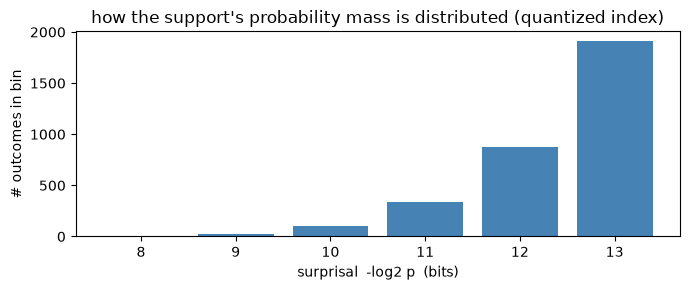

In [7]:
idx = big.quantized_index(max_bits=14.0, bin_width_bits=1.0)
s = idx.summary()
print('support outcomes within the 14-bit budget : %d  (of 100000; truncated=%s)' % (s['total_count'], s['truncated']))
print('rank-0 (mode)      :', idx.get(0))
print('outcomes at ranks 100-102:', [(''.join(v), round(np.exp(lp), 5)) for v, lp in idx.slice(100, 3)])

# the probability-bin histogram of the whole support, computed without materializing it
bins = sorted(s['counts'])
fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(bins, [s['counts'][b] for b in bins], color='steelblue')
ax.set_xlabel('surprisal  -log2 p  (bits)'); ax.set_ylabel('# outcomes in bin')
ax.set_title('how the support\'s probability mass is distributed (quantized index)')
plt.tight_layout(); plt.show()

## When a support is not enumerable

Continuous distributions have no countable support, and a few structured ones (a `Conditional`, whose conditioning variable isn't enumerable) decline as well - both raise `EnumerationError` rather than silently approximating.


In [8]:
try:
    GaussianDistribution(0.0, 1.0).enumerator()
except EnumerationError as err:
    print('Gaussian    -> EnumerationError:', str(err)[:55])

from mixle.stats import ConditionalDistribution
try:
    ConditionalDistribution({'p': CategoricalDistribution({'x': 0.9, 'y': 0.1})}).enumerator().top_k(1)
except EnumerationError as err:
    print('Conditional -> EnumerationError:', str(err)[:55])

Gaussian    -> EnumerationError: GaussianDistribution does not support enumeration
Conditional -> EnumerationError: ConditionalDistribution does not support enumeration: t
